Total clients in portfolio: 32581
Clients after cleaning missing data: 28638

Overall Default Rate: 21.66%


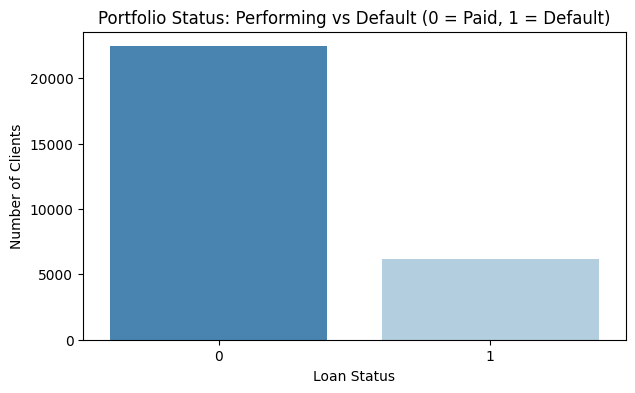

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the credit risk dataset
file_name = 'credit_risk_dataset.csv'
df = pd.read_csv(file_name)

# 2. overview of the portfolio
print(f"Total clients in portfolio: {len(df)}")

# 3. Data Cleaning
df_clean = df.dropna().copy()
print(f"Clients after cleaning missing data: {len(df_clean)}")

# 4. Exploratory Data Analysis
default_rate = df_clean['loan_status'].mean() * 100
print(f"\nOverall Default Rate: {default_rate:.2f}%")

# 5. Create a chart
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x='loan_status', hue='loan_status', palette='Blues_r', legend=False)
plt.title('Portfolio Status: Performing vs Default (0 = Paid, 1 = Default)')
plt.xlabel('Loan Status')
plt.ylabel('Number of Clients')
plt.show()



In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Select the features for the model
features = ['person_income', 'loan_amnt', 'loan_int_rate', 'person_age']
X = df_clean[features]
y = df_clean['loan_status']

# 2. Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Logistic Regression model (Fixing the convergence warning)
model = LogisticRegression(max_iter=1000)

# 4. Train the model using the training set
model.fit(X_train, y_train)

# 5. Make predictions using the testing set
predictions = model.predict(X_test)

# 6. Calculate and display the accuracy score
accuracy = accuracy_score(y_test, predictions) * 100
print(f"Model successfully trained! Accuracy: {accuracy:.2f}%")


Model successfully trained! Accuracy: 81.55%


In [9]:
import pandas as pd

# 1. Create a hypothetical new client profile
new_client_data = {
    'person_income': [45000],
    'loan_amnt': [15000],
    'loan_int_rate': [10.5],
    'person_age': [28]
}
new_client = pd.DataFrame(new_client_data)

# 2. Calculate the specific Probability of Default
probabilities = model.predict_proba(new_client)
default_probability = probabilities[0][1] * 100
print(f"Client Default Probability: {default_probability:.2f}%")

# 3. Business Decision Rule
risk_threshold = 25.0

print("-" * 30)
if default_probability > risk_threshold:
    print("Bank Decision: REJECT the loan. The risk is too high.")
else:
    print("Bank Decision: APPROVE the loan. The risk is acceptable.")

Client Default Probability: 32.12%
------------------------------
Bank Decision: REJECT the loan. The risk is too high.
